In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("churn Analysis.csv")

print("dataset loaded successfully!")
print("Rows:",df.shape[0])
print("Columns:",df.shape[1])

dataset loaded successfully!
Rows: 7043
Columns: 25


In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,FALSE,Tenure Group,Risk Score,Monthly charges group
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,Month-to-month,Yes,Electronic check,29.85,29.85,No,True,New,4,Low
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,One year,No,Mailed check,56.95,1889.5,No,True,Established,1,Medium
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,True,New,3,Medium
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,One year,No,Bank transfer (automatic),42.30,1840.75,No,True,Established,0,Medium
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,True,New,5,High


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customerID              7043 non-null   object 
 1   gender                  7043 non-null   object 
 2   SeniorCitizen           7043 non-null   int64  
 3   Partner                 7043 non-null   object 
 4   Dependents              7043 non-null   object 
 5   tenure                  7043 non-null   int64  
 6   PhoneService            7043 non-null   object 
 7   MultipleLines           7043 non-null   object 
 8   InternetService         7043 non-null   object 
 9   OnlineSecurity          7043 non-null   object 
 10  OnlineBackup            7043 non-null   object 
 11  DeviceProtection        7043 non-null   object 
 12  TechSupport             7043 non-null   object 
 13  StreamingTV             7043 non-null   object 
 14  StreamingMovies         7043 non-null   

In [ ]:
df_clean = df.iloc[:, :21].copy()

print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])

Rows: 7043
Columns: 21


In [ ]:
df_clean.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [ ]:
missing = df_clean.isnull().sum()

missing[missing > 0]

,0


In [ ]:
df_clean['TotalCharges'].value_counts().head(10)

,count
TotalCharges,
,11
20.2,11
19.75,9
20.05,8
19.9,8
19.65,8
19.55,7
45.3,7
20.15,6


In [ ]:
df_clean['TotalCharges'].tail(10)

,TotalCharges
7033,2625.25
7034,6886.25
7035,1495.1
7036,743.3
7037,1419.4
7038,1990.5
7039,7362.9
7040,346.45
7041,306.6
7042,6844.5


In [ ]:
pd.to_numeric(df_clean['TotalCharges'], errors='coerce').isna().sum()

np.int64(11)

In [ ]:
df_clean.loc[
    pd.to_numeric(df_clean['TotalCharges'], errors='coerce').isna(),
    ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']
]

,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


In [ ]:
df_clean['TotalCharges'] = pd.to_numeric(
    df_clean['TotalCharges'],
    errors='coerce'
)

In [ ]:
df_clean['TotalCharges'].dtype

dtype('float64')

In [ ]:
df_clean['TotalCharges'].isnull().sum()

np.int64(11)

In [ ]:
df_clean[df_clean['TotalCharges'].isnull()][
    ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


In [ ]:
df_clean.duplicated().sum()

np.int64(0)

In [ ]:
df_clean['customerID'].duplicated().sum()

np.int64(0)

In [ ]:
df_clean.isnull().sum().sort_values(ascending=False)

,0
TotalCharges,11
gender,0
SeniorCitizen,0
Partner,0
customerID,0
Dependents,0
tenure,0
MultipleLines,0
PhoneService,0
OnlineSecurity,0


In [ ]:
for col in ['gender', 'Partner', 'Dependents', 'InternetService', 'Contract', 'PaymentMethod', 'Churn']:
    print(f"\n--- {col} ---")
    print(df_clean[col].unique())


--- gender ---
['Female' 'Male']

--- Partner ---
['Yes' 'No']

--- Dependents ---
['No' 'Yes']

--- InternetService ---
['DSL' 'Fiber optic' 'No']

--- Contract ---
['Month-to-month' 'One year' 'Two year']

--- PaymentMethod ---
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

--- Churn ---
['No' 'Yes']


In [ ]:
df_clean[['tenure', 'MonthlyCharges', 'TotalCharges']].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


In [ ]:
df_analysis = df_clean.copy()

In [ ]:
df_analysis['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [ ]:
df_analysis['Churn'].value_counts(normalize=True).mul(100).round(2)

,proportion
Churn,
No,73.46
Yes,26.54


In [ ]:
df_analysis['Churn_Encoded'] = df_analysis['Churn'].map({
    'No': 0,
    'Yes': 1
})

In [ ]:
df_analysis[['Churn', 'Churn_Encoded']].head(10)

,Churn,Churn_Encoded
0,No,0
1,No,0
2,Yes,1
3,No,0
4,Yes,1
5,Yes,1
6,No,0
7,No,0
8,Yes,1
9,No,0


In [ ]:
df_analysis[['tenure', 'MonthlyCharges', 'TotalCharges']].describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80


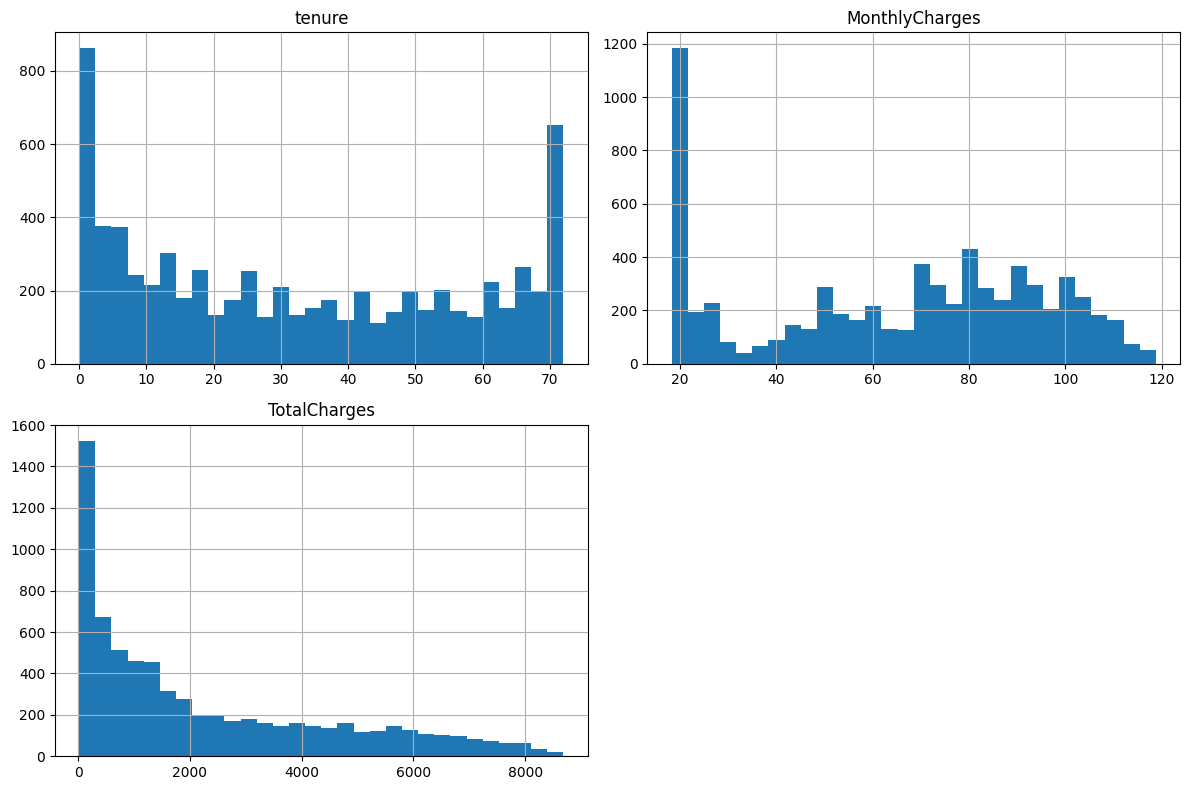

In [ ]:
import matplotlib.pyplot as plt

df_analysis[['tenure', 'MonthlyCharges', 'TotalCharges']].hist(
    figsize=(12, 8),
    bins=30
)

plt.tight_layout()
plt.show()

In [ ]:
df_analysis[['tenure', 'MonthlyCharges', 'TotalCharges']].median()

,0
tenure,29.000
MonthlyCharges,70.350
TotalCharges,1397.475


In [ ]:
df_analysis.groupby('Churn')[[
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]].mean().round(2)

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.57,61.27,2555.34
Yes,17.98,74.44,1531.80


In [ ]:
df_analysis.groupby('Churn')[[
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]].median().round(2)

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,38.0,64.43,1683.60
Yes,10.0,79.65,703.55


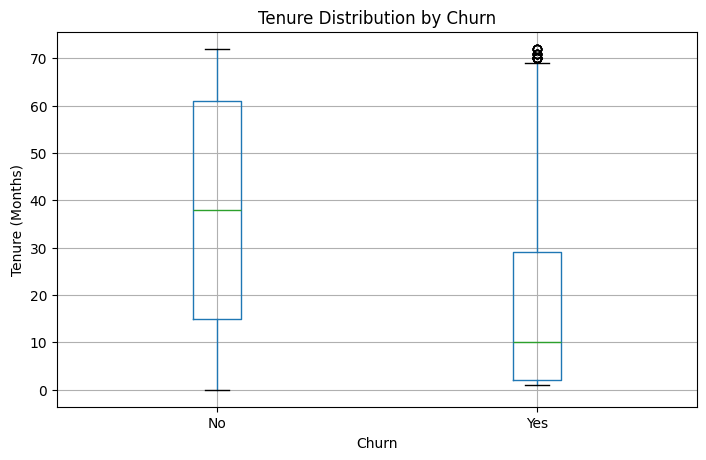

In [ ]:
import matplotlib.pyplot as plt

df_analysis.boxplot(
    column='tenure',
    by='Churn',
    figsize=(8, 5)
)

plt.title('Tenure Distribution by Churn')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')
plt.show()

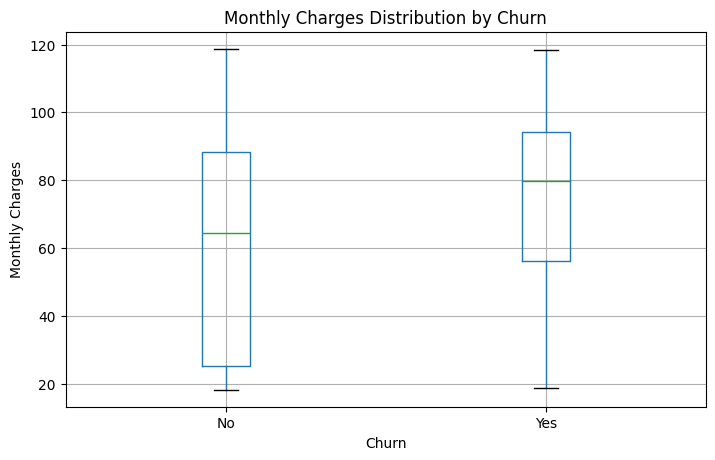

In [ ]:
df_analysis.boxplot(
    column='MonthlyCharges',
    by='Churn',
    figsize=(8, 5)
)

plt.title('Monthly Charges Distribution by Churn')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.show()

In [ ]:
df_analysis.groupby('Churn')['MonthlyCharges'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
).round(2)

,count,mean,median,std,min,max
Churn,,,,,,
No,5174,61.27,64.43,31.09,18.25,118.75
Yes,1869,74.44,79.65,24.67,18.85,118.35


In [ ]:
contract_churn = (
    df_analysis.groupby('Contract')['Churn_Encoded']
    .agg(['count', 'sum', 'mean'])
    .reset_index()
)

contract_churn.columns = [
    'Contract',
    'Total_Customers',
    'Churned_Customers',
    'Churn_Rate'
]

contract_churn['Churn_Rate'] = (
    contract_churn['Churn_Rate'] * 100
).round(2)

contract_churn.sort_values('Churn_Rate', ascending=False)

,Contract,Total_Customers,Churned_Customers,Churn_Rate
0,Month-to-month,3875,1655,42.71
1,One year,1473,166,11.27
2,Two year,1695,48,2.83


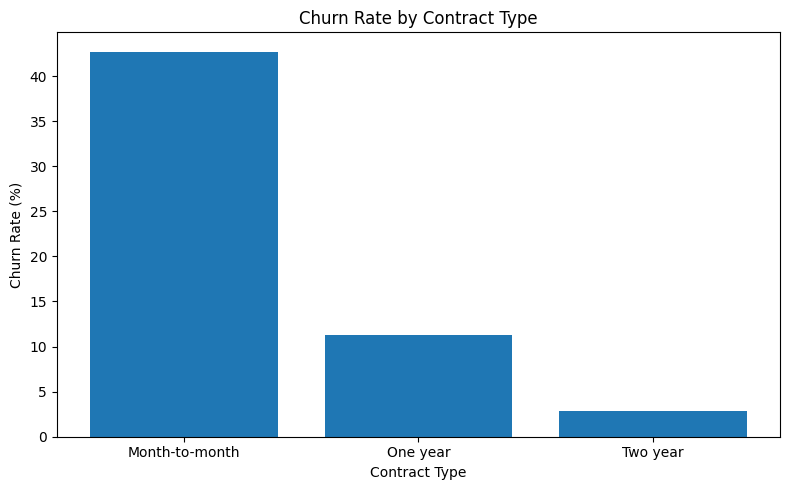

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    contract_churn['Contract'],
    contract_churn['Churn_Rate']
)

plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')

plt.tight_layout()
plt.show()

In [ ]:
internet_churn = (
    df_analysis.groupby('InternetService')['Churn_Encoded']
    .agg(['count', 'sum', 'mean'])
    .reset_index()
)

internet_churn.columns = [
    'InternetService',
    'Total_Customers',
    'Churned_Customers',
    'Churn_Rate'
]

internet_churn['Churn_Rate'] = (
    internet_churn['Churn_Rate'] * 100
).round(2)

internet_churn.sort_values('Churn_Rate', ascending=False)

,InternetService,Total_Customers,Churned_Customers,Churn_Rate
1,Fiber optic,3096,1297,41.89
0,DSL,2421,459,18.96
2,No,1526,113,7.40


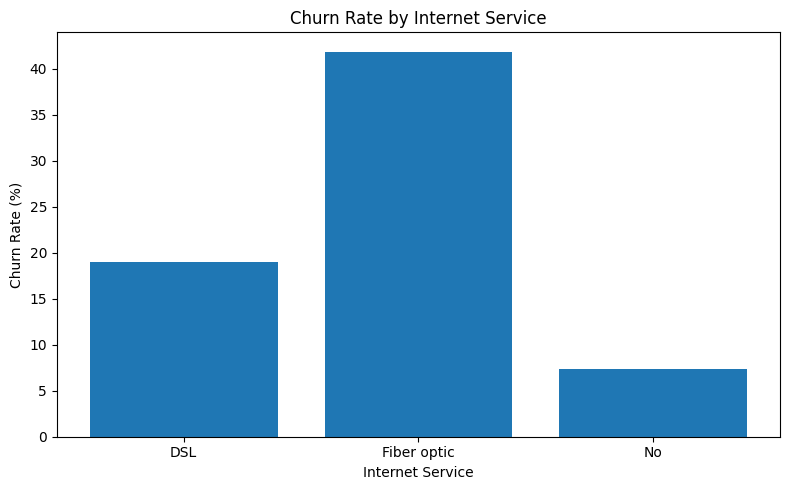

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    internet_churn['InternetService'],
    internet_churn['Churn_Rate']
)

plt.title('Churn Rate by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Churn Rate (%)')

plt.tight_layout()
plt.show()

In [ ]:
df_analysis['Tenure_Group'] = pd.cut(
    df_analysis['tenure'],
    bins=[-1, 12, 24, 48, 72],
    labels=['New', 'Early', 'Established', 'Loyal']
)

In [ ]:
df_analysis['Tenure_Group'].value_counts().sort_index()

,count
Tenure_Group,
New,2186
Early,1024
Established,1594
Loyal,2239


In [ ]:
tenure_churn = (
    df_analysis.groupby('Tenure_Group', observed=True)['Churn_Encoded']
    .agg(['count', 'sum', 'mean'])
    .reset_index()
)

tenure_churn.columns = [
    'Tenure_Group',
    'Total_Customers',
    'Churned_Customers',
    'Churn_Rate'
]

tenure_churn['Churn_Rate'] = (
    tenure_churn['Churn_Rate'] * 100
).round(2)

tenure_churn

,Tenure_Group,Total_Customers,Churned_Customers,Churn_Rate
0,New,2186,1037,47.44
1,Early,1024,294,28.71
2,Established,1594,325,20.39
3,Loyal,2239,213,9.51


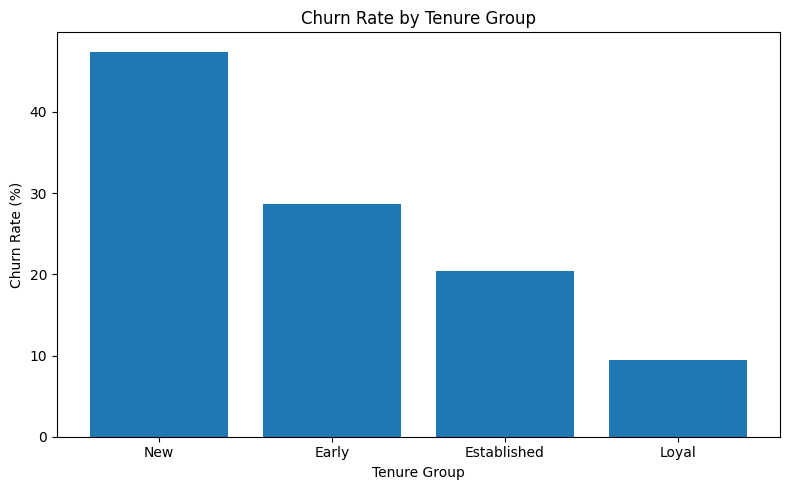

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    tenure_churn['Tenure_Group'].astype(str),
    tenure_churn['Churn_Rate']
)

plt.title('Churn Rate by Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')

plt.tight_layout()
plt.show()

In [ ]:
payment_churn = (
    df_analysis.groupby('PaymentMethod')['Churn_Encoded']
    .agg(['count', 'sum', 'mean'])
    .reset_index()
)

payment_churn.columns = [
    'PaymentMethod',
    'Total_Customers',
    'Churned_Customers',
    'Churn_Rate'
]

payment_churn['Churn_Rate'] = (
    payment_churn['Churn_Rate'] * 100
).round(2)

payment_churn.sort_values('Churn_Rate', ascending=False)

,PaymentMethod,Total_Customers,Churned_Customers,Churn_Rate
2,Electronic check,2365,1071,45.29
3,Mailed check,1612,308,19.11
0,Bank transfer (automatic),1544,258,16.71
1,Credit card (automatic),1522,232,15.24


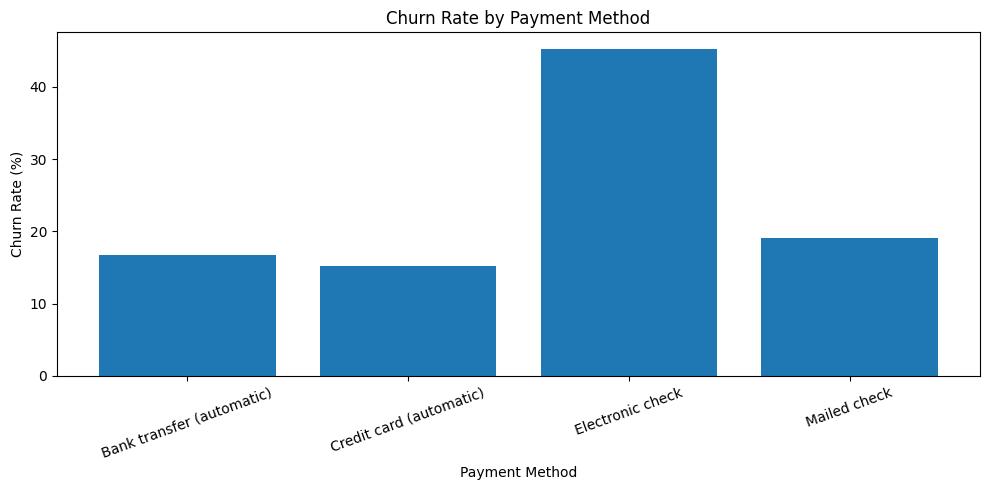

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    payment_churn['PaymentMethod'],
    payment_churn['Churn_Rate']
)

plt.title('Churn Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [ ]:
tech_churn = (
    df_analysis.groupby('TechSupport')['Churn_Encoded']
    .agg(['count', 'sum', 'mean'])
    .reset_index()
)

tech_churn.columns = [
    'TechSupport',
    'Total_Customers',
    'Churned_Customers',
    'Churn_Rate'
]

tech_churn['Churn_Rate'] = (
    tech_churn['Churn_Rate'] * 100
).round(2)

tech_churn.sort_values('Churn_Rate', ascending=False)

,TechSupport,Total_Customers,Churned_Customers,Churn_Rate
0,No,3473,1446,41.64
2,Yes,2044,310,15.17
1,No internet service,1526,113,7.40


In [ ]:
security_churn = (
    df_analysis.groupby('OnlineSecurity')['Churn_Encoded']
    .agg(['count', 'sum', 'mean'])
    .reset_index()
)

security_churn.columns = [
    'OnlineSecurity',
    'Total_Customers',
    'Churned_Customers',
    'Churn_Rate'
]

security_churn['Churn_Rate'] = (
    security_churn['Churn_Rate'] * 100
).round(2)

security_churn.sort_values('Churn_Rate', ascending=False)

,OnlineSecurity,Total_Customers,Churned_Customers,Churn_Rate
0,No,3498,1461,41.77
2,Yes,2019,295,14.61
1,No internet service,1526,113,7.40


In [ ]:
payment_churn = (
    df_analysis.groupby('PaymentMethod')['Churn_Encoded']
    .agg(['count', 'sum', 'mean'])
    .reset_index()
)

payment_churn.columns = [
    'PaymentMethod',
    'Total_Customers',
    'Churned_Customers',
    'Churn_Rate'
]

payment_churn['Churn_Rate'] = (
    payment_churn['Churn_Rate'] * 100
).round(2)

payment_churn.sort_values('Churn_Rate', ascending=False)

,PaymentMethod,Total_Customers,Churned_Customers,Churn_Rate
2,Electronic check,2365,1071,45.29
3,Mailed check,1612,308,19.11
0,Bank transfer (automatic),1544,258,16.71
1,Credit card (automatic),1522,232,15.24


In [ ]:
payment_churn = (
    df_analysis.groupby('PaymentMethod')['Churn_Encoded']
    .agg(['count', 'sum', 'mean'])
    .reset_index()
)

payment_churn.columns = [
    'PaymentMethod',
    'Total_Customers',
    'Churned_Customers',
    'Churn_Rate'
]

payment_churn['Churn_Rate'] = (
    payment_churn['Churn_Rate'] * 100
).round(2)

payment_churn.sort_values('Churn_Rate', ascending=False)

,PaymentMethod,Total_Customers,Churned_Customers,Churn_Rate
2,Electronic check,2365,1071,45.29
3,Mailed check,1612,308,19.11
0,Bank transfer (automatic),1544,258,16.71
1,Credit card (automatic),1522,232,15.24


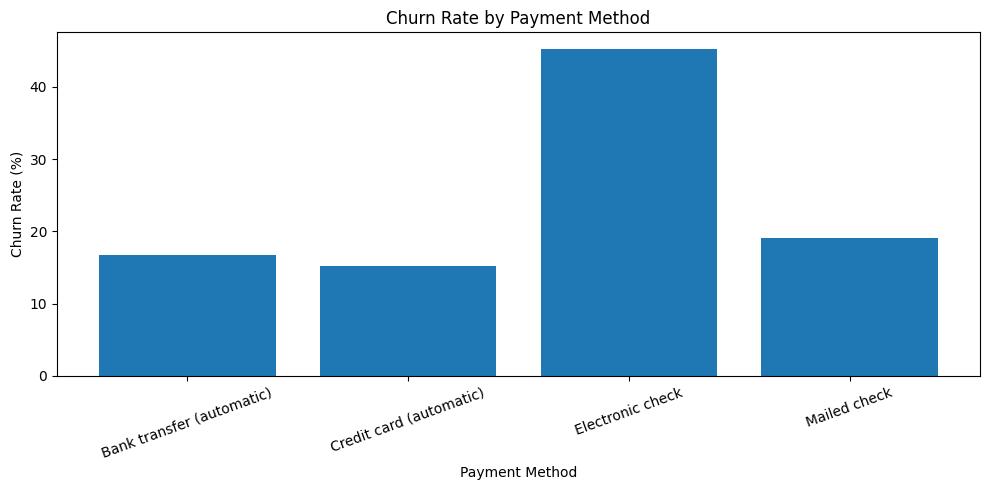

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    payment_churn['PaymentMethod'],
    payment_churn['Churn_Rate']
)

plt.title('Churn Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [ ]:
contract_internet = (
    df_analysis
    .groupby(['Contract', 'InternetService'])['Churn_Encoded']
    .agg(['count', 'sum', 'mean'])
    .reset_index()
)

contract_internet.columns = [
    'Contract',
    'InternetService',
    'Total_Customers',
    'Churned_Customers',
    'Churn_Rate'
]

contract_internet['Churn_Rate'] = (
    contract_internet['Churn_Rate'] * 100
).round(2)

contract_internet.sort_values(
    'Churn_Rate',
    ascending=False
)

,Contract,InternetService,Total_Customers,Churned_Customers,Churn_Rate
1,Month-to-month,Fiber optic,2128,1162,54.61
0,Month-to-month,DSL,1223,394,32.22
4,One year,Fiber optic,539,104,19.29
2,Month-to-month,No,524,99,18.89
3,One year,DSL,570,53,9.30
7,Two year,Fiber optic,429,31,7.23
5,One year,No,364,9,2.47
6,Two year,DSL,628,12,1.91
8,Two year,No,638,5,0.78


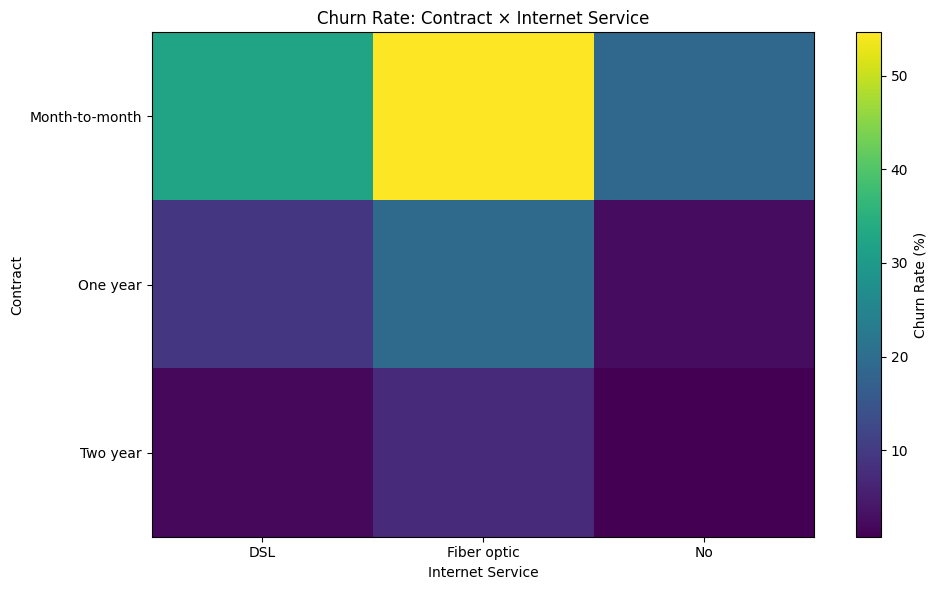

In [ ]:
pivot_ci = contract_internet.pivot(
    index='Contract',
    columns='InternetService',
    values='Churn_Rate'
)

plt.figure(figsize=(10, 6))

plt.imshow(pivot_ci, aspect='auto')

plt.xticks(
    range(len(pivot_ci.columns)),
    pivot_ci.columns
)

plt.yticks(
    range(len(pivot_ci.index)),
    pivot_ci.index
)

plt.xlabel('Internet Service')
plt.ylabel('Contract')
plt.title('Churn Rate: Contract × Internet Service')

plt.colorbar(label='Churn Rate (%)')

plt.tight_layout()
plt.show()

In [ ]:
df_analysis['Risk_Score'] = (
    (df_analysis['Contract'] == 'Month-to-month').astype(int)
    + (df_analysis['tenure'] <= 12).astype(int)
    + (df_analysis['InternetService'] == 'Fiber optic').astype(int)
    + (df_analysis['TechSupport'] == 'No').astype(int)
    + (df_analysis['OnlineSecurity'] == 'No').astype(int)
)

df_analysis[['customerID', 'Risk_Score', 'Churn']].head(10)

,customerID,Risk_Score,Churn
0,7590-VHVEG,4,No
1,5575-GNVDE,1,No
2,3668-QPYBK,3,Yes
3,7795-CFOCW,0,No
4,9237-HQITU,5,Yes
5,9305-CDSKC,5,Yes
6,1452-KIOVK,4,No
7,6713-OKOMC,3,No
8,7892-POOKP,3,Yes
9,6388-TABGU,1,No


In [ ]:
risk_churn = (
    df_analysis
    .groupby('Risk_Score')['Churn_Encoded']
    .agg(['count', 'sum', 'mean'])
    .reset_index()
)

risk_churn.columns = [
    'Risk_Score',
    'Total_Customers',
    'Churned_Customers',
    'Churn_Rate'
]

risk_churn['Churn_Rate'] = (
    risk_churn['Churn_Rate'] * 100
).round(2)

risk_churn

,Risk_Score,Total_Customers,Churned_Customers,Churn_Rate
0,0,1456,31,2.13
1,1,1076,77,7.16
2,2,1334,232,17.39
3,3,1088,318,29.23
4,4,1325,654,49.36
5,5,764,557,72.91


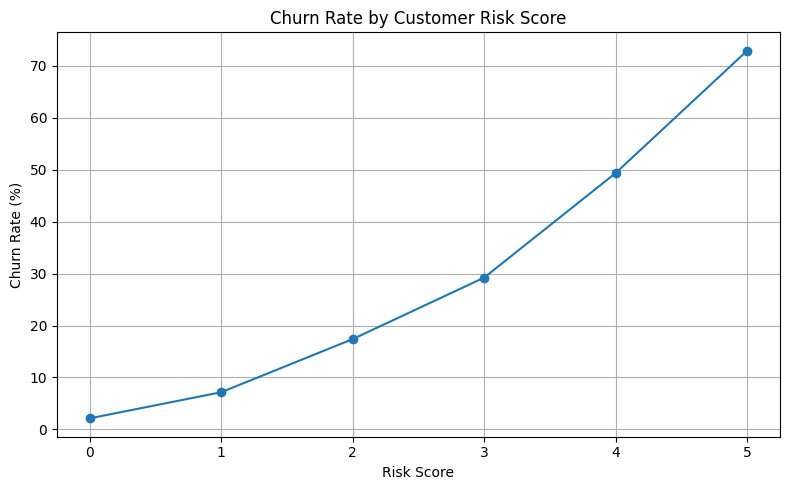

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    risk_churn['Risk_Score'],
    risk_churn['Churn_Rate'],
    marker='o'
)

plt.title('Churn Rate by Customer Risk Score')
plt.xlabel('Risk Score')
plt.ylabel('Churn Rate (%)')
plt.xticks(range(0, 6))
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
high_risk_customers = df_analysis[
    df_analysis['Risk_Score'] >= 4
].copy()

high_risk_customers = high_risk_customers.sort_values(
    ['Risk_Score', 'MonthlyCharges'],
    ascending=[False, False]
)

high_risk_customers[
    [
        'customerID',
        'tenure',
        'Contract',
        'InternetService',
        'TechSupport',
        'OnlineSecurity',
        'MonthlyCharges',
        'Risk_Score',
        'Churn'
    ]
].head(20)

,customerID,tenure,Contract,InternetService,TechSupport,OnlineSecurity,MonthlyCharges,Risk_Score,Churn
678,5760-IFJOZ,3,Month-to-month,Fiber optic,No,No,107.95,5,No
2294,2027-FECZV,12,Month-to-month,Fiber optic,No,No,106.70,5,Yes
6894,1400-MMYXY,3,Month-to-month,Fiber optic,No,No,105.90,5,Yes
4826,3389-YGYAI,8,Month-to-month,Fiber optic,No,No,105.50,5,Yes
3085,5052-PNLOS,3,Month-to-month,Fiber optic,No,No,105.35,5,Yes
2387,6734-GMPVK,5,Month-to-month,Fiber optic,No,No,105.30,5,No
2582,7145-FEJWU,12,Month-to-month,Fiber optic,No,No,105.30,5,No
3956,4587-VVTOX,6,Month-to-month,Fiber optic,No,No,105.30,5,Yes
5933,6496-SLWHQ,3,Month-to-month,Fiber optic,No,No,105.00,5,Yes
4738,2369-UAPKZ,5,Month-to-month,Fiber optic,No,No,104.10,5,Yes


In [ ]:
high_risk_summary = (
    df_analysis['Risk_Score']
    .value_counts()
    .sort_index()
)

high_risk_summary

,count
Risk_Score,
0,1456
1,1076
2,1334
3,1088
4,1325
5,764


In [ ]:
high_risk_revenue = (
    high_risk_customers['MonthlyCharges']
    .sum()
)

print(
    "High-risk customers:",
    len(high_risk_customers)
)

print(
    "Monthly revenue from high-risk customers: $",
    round(high_risk_revenue, 2)
)

High-risk customers: 2089
Monthly revenue from high-risk customers: $ 160266.5


In [ ]:
high_risk_churn = (
    high_risk_customers['Churn']
    .value_counts()
)

high_risk_churn

,count
Churn,
Yes,1211
No,878


In [ ]:
revenue_at_risk = (
    df_analysis.loc[
        df_analysis['Churn'] == 'Yes',
        'MonthlyCharges'
    ].sum()
)

print(
    "Monthly revenue associated with churned customers: $",
    round(revenue_at_risk, 2)
)

Monthly revenue associated with churned customers: $ 139130.85


In [ ]:
revenue_comparison = (
    df_analysis
    .groupby('Churn')['MonthlyCharges']
    .agg(['count', 'sum', 'mean'])
    .reset_index()
)

revenue_comparison.columns = [
    'Churn',
    'Customers',
    'Total_Monthly_Revenue',
    'Average_Monthly_Charge'
]

revenue_comparison.round(2)

,Churn,Customers,Total_Monthly_Revenue,Average_Monthly_Charge
0,No,5174,316985.75,61.27
1,Yes,1869,139130.85,74.44


In [ ]:
total_monthly_revenue = df_analysis['MonthlyCharges'].sum()

churned_revenue_pct = (
    revenue_at_risk / total_monthly_revenue
) * 100

print(
    "Percentage of total monthly revenue associated with churned customers:",
    round(churned_revenue_pct, 2),
    "%"
)

Percentage of total monthly revenue associated with churned customers: 30.5 %


In [ ]:
segment_revenue = (
    df_analysis[df_analysis['Churn'] == 'Yes']
    .groupby(['Contract', 'InternetService'])
    .agg(
        Churned_Customers=('customerID', 'count'),
        Churned_Monthly_Revenue=('MonthlyCharges', 'sum'),
        Average_Monthly_Charge=('MonthlyCharges', 'mean')
    )
    .reset_index()
)

segment_revenue['Churned_Monthly_Revenue'] = (
    segment_revenue['Churned_Monthly_Revenue']
    .round(2)
)

segment_revenue['Average_Monthly_Charge'] = (
    segment_revenue['Average_Monthly_Charge']
    .round(2)
)

segment_revenue.sort_values(
    'Churned_Monthly_Revenue',
    ascending=False
)

,Contract,InternetService,Churned_Customers,Churned_Monthly_Revenue,Average_Monthly_Charge
1,Month-to-month,Fiber optic,1162,100482.00,86.47
0,Month-to-month,DSL,394,18367.25,46.62
4,One year,Fiber optic,104,10571.95,101.65
3,One year,DSL,53,3356.25,63.33
7,Two year,Fiber optic,31,3246.10,104.71
2,Month-to-month,No,99,1997.85,20.18
6,Two year,DSL,12,805.70,67.14
5,One year,No,9,190.25,21.14
8,Two year,No,5,113.50,22.70


In [ ]:
df_analysis['Lifetime_Revenue'] = (
    df_analysis['MonthlyCharges'] * df_analysis['tenure']
)

df_analysis[
    [
        'customerID',
        'tenure',
        'MonthlyCharges',
        'Lifetime_Revenue',
        'Churn'
    ]
].head(10)

,customerID,tenure,MonthlyCharges,Lifetime_Revenue,Churn
0,7590-VHVEG,1,29.85,29.85,No
1,5575-GNVDE,34,56.95,1936.30,No
2,3668-QPYBK,2,53.85,107.70,Yes
3,7795-CFOCW,45,42.30,1903.50,No
4,9237-HQITU,2,70.70,141.40,Yes
5,9305-CDSKC,8,99.65,797.20,Yes
6,1452-KIOVK,22,89.10,1960.20,No
7,6713-OKOMC,10,29.75,297.50,No
8,7892-POOKP,28,104.80,2934.40,Yes
9,6388-TABGU,62,56.15,3481.30,No


In [ ]:
lifetime_revenue_churn = (
    df_analysis
    .groupby('Churn')['Lifetime_Revenue']
    .agg(['count', 'mean', 'median', 'sum'])
    .reset_index()
)

lifetime_revenue_churn.round(2)

,Churn,count,mean,median,sum
0,No,5174,2549.77,1687.12,13192514.55
1,Yes,1869,1531.61,700.00,2862576.90


In [ ]:
high_value_churned = df_analysis[
    (df_analysis['Churn'] == 'Yes') &
    (df_analysis['Lifetime_Revenue'] >=
     df_analysis['Lifetime_Revenue'].quantile(0.75))
].copy()

high_value_churned = high_value_churned.sort_values(
    'Lifetime_Revenue',
    ascending=False
)

high_value_churned[
    [
        'customerID',
        'tenure',
        'MonthlyCharges',
        'Lifetime_Revenue',
        'Contract',
        'InternetService',
        'Churn'
    ]
].head(20)

,customerID,tenure,MonthlyCharges,Lifetime_Revenue,Contract,InternetService,Churn
4610,2889-FPWRM,72,117.80,8481.60,One year,Fiber optic,Yes
6537,1444-VVSGW,70,115.65,8095.50,One year,Fiber optic,Yes
1306,0201-OAMXR,70,115.55,8088.50,One year,Fiber optic,Yes
6038,1555-DJEQW,70,114.20,7994.00,Two year,Fiber optic,Yes
5127,8199-ZLLSA,67,118.35,7929.45,One year,Fiber optic,Yes
3890,3886-CERTZ,72,109.25,7866.00,One year,Fiber optic,Yes
6289,9053-JZFKV,67,116.20,7785.40,Two year,Fiber optic,Yes
3040,7317-GGVPB,71,108.60,7710.60,Two year,Fiber optic,Yes
5581,5271-YNWVR,68,113.15,7694.20,Two year,Fiber optic,Yes
975,2834-JRTUA,71,108.05,7671.55,Two year,Fiber optic,Yes


In [ ]:
lifetime_revenue_75th = (
    df_analysis['Lifetime_Revenue'].quantile(0.75)
)

high_value_high_risk = df_analysis[
    (df_analysis['Risk_Score'] >= 4) &
    (df_analysis['Lifetime_Revenue'] >= lifetime_revenue_75th) &
    (df_analysis['Churn'] == 'No')
].copy()

In [ ]:
priority_customers = high_value_high_risk.sort_values(
    ['Risk_Score', 'MonthlyCharges', 'Lifetime_Revenue'],
    ascending=[False, False, False]
)

priority_customers[
    [
        'customerID',
        'tenure',
        'Contract',
        'InternetService',
        'TechSupport',
        'OnlineSecurity',
        'MonthlyCharges',
        'Lifetime_Revenue',
        'Risk_Score',
        'Churn'
    ]
].head(20)

,customerID,tenure,Contract,InternetService,TechSupport,OnlineSecurity,MonthlyCharges,Lifetime_Revenue,Risk_Score,Churn
1661,3761-FLYZI,65,Month-to-month,Fiber optic,No,No,108.80,7072.00,4,No
5444,1833-TCXKK,45,Month-to-month,Fiber optic,No,No,107.75,4848.75,4,No
2474,5630-IXDXV,47,Month-to-month,Fiber optic,No,No,106.35,4998.45,4,No
4572,6377-WHAOX,60,Month-to-month,Fiber optic,No,No,106.15,6369.00,4,No
5298,5647-FXOTP,60,Month-to-month,Fiber optic,No,No,105.90,6354.00,4,No
3783,1469-LBJQJ,66,Month-to-month,Fiber optic,No,No,105.20,6943.20,4,No
3472,4840-ORQXB,56,Month-to-month,Fiber optic,No,No,104.75,5866.00,4,No
4264,8818-DOPVL,46,Month-to-month,Fiber optic,No,No,104.45,4804.70,4,No
5187,2080-CAZNM,41,Month-to-month,Fiber optic,No,No,104.40,4280.40,4,No
6380,2378-VTKDH,65,Month-to-month,Fiber optic,No,No,104.35,6782.75,4,No


In [ ]:
potential_revenue_at_risk = (
    priority_customers['MonthlyCharges'].sum()
)

print(
    "High-value, high-risk customers:",
    len(priority_customers)
)

print(
    "Potential monthly revenue at risk: $",
    round(potential_revenue_at_risk, 2)
)

High-value, high-risk customers: 116
Potential monthly revenue at risk: $ 10769.65


In [ ]:
correlation_data = df_analysis[
    [
        'tenure',
        'MonthlyCharges',
        'TotalCharges',
        'Churn_Encoded',
        'Risk_Score'
    ]
]

correlation_matrix = correlation_data.corr().round(2)

correlation_matrix

,tenure,MonthlyCharges,TotalCharges,Churn_Encoded,Risk_Score
tenure,1.00,0.25,0.83,-0.35,-0.55
MonthlyCharges,0.25,1.00,0.65,0.19,0.40
TotalCharges,0.83,0.65,1.00,-0.20,-0.23
Churn_Encoded,-0.35,0.19,-0.20,1.00,0.50
Risk_Score,-0.55,0.40,-0.23,0.50,1.00


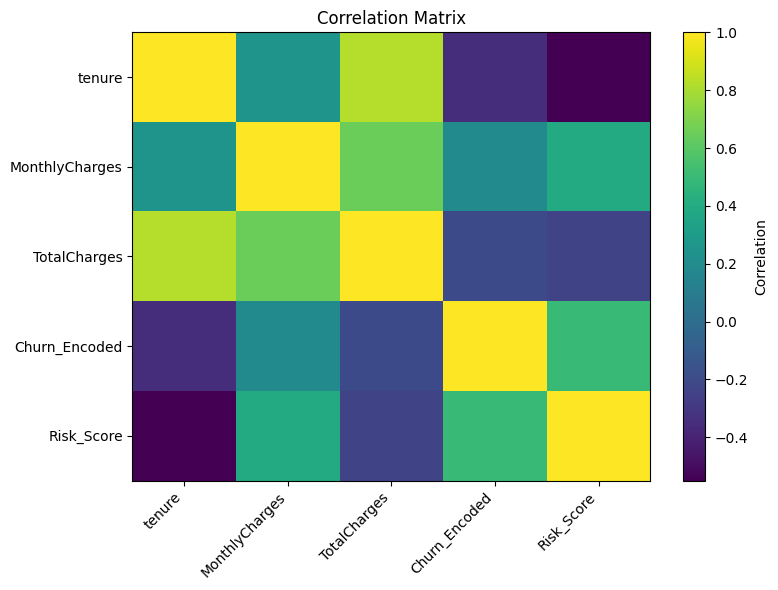

In [ ]:
plt.figure(figsize=(8, 6))

plt.imshow(
    correlation_matrix,
    aspect='auto'
)

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index
)

plt.colorbar(label='Correlation')

plt.title('Correlation Matrix')

plt.tight_layout()
plt.show()

In [ ]:
df_analysis.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn',
 'Churn_Encoded',
 'Tenure_Group',
 'Risk_Score',
 'Lifetime_Revenue']

In [ ]:
X = df_analysis.drop(
    columns=['customerID', 'Churn', 'Churn_Encoded']
)

y = df_analysis['Churn_Encoded']

print("Features:", X.shape)
print("Target:", y.shape)

Features: (7043, 22)
Target: (7043,)


In [ ]:
numerical_features = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = X.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Risk_Score', 'Lifetime_Revenue']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Tenure_Group']


In [ ]:
print(y.value_counts())

print("\nPercentage:")
print(
    (y.value_counts(normalize=True) * 100).round(2)
)

Churn_Encoded
0    5174
1    1869
Name: count, dtype: int64

Percentage:
Churn_Encoded
0    73.46
1    26.54
Name: proportion, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (5634, 22)
Testing features: (1409, 22)
Training target: (5634,)
Testing target: (1409,)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numerical_features
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore',
                drop='first'
            ),
            categorical_features
        )
    ]
)

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [ ]:
print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("Original testing shape:", X_test.shape)
print("Processed testing shape:", X_test_processed.shape)

Original training shape: (5634, 22)
Processed training shape: (5634, 35)
Original testing shape: (1409, 22)
Processed testing shape: (1409, 35)


In [ ]:
preprocessor.fit_transform(X_train)

array([[-0.44177295,  0.10237124, -0.52197565, ...,  1.        ,
         0.        ,  0.        ],
       [-0.44177295, -0.71174346,  0.33747781, ...,  0.        ,
         0.        ,  0.        ],
       [-0.44177295, -0.79315493, -0.80901319, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 2.2636062 , -0.30468611,  1.25666162, ...,  1.        ,
         0.        ,  0.        ],
       [-0.44177295, -0.34539184, -1.47766135, ...,  0.        ,
         0.        ,  0.        ],
       [-0.44177295, -1.07809507, -1.46936546, ...,  0.        ,
         0.        ,  1.        ]])

In [ ]:
preprocessor.transform(X_test)

array([[-0.44177295,  1.60848343,  1.62997635, ...,  0.        ,
         1.        ,  0.        ],
       [ 2.2636062 , -0.9966836 ,  1.16872526, ...,  0.        ,
         0.        ,  1.        ],
       [-0.44177295,  0.34660565,  0.44532428, ...,  1.        ,
         0.        ,  0.        ],
       ...,
       [-0.44177295, -1.11880081, -1.46936546, ...,  0.        ,
         0.        ,  1.        ],
       [-0.44177295,  0.95719167, -1.50088982, ...,  0.        ,
         1.        ,  0.        ],
       [-0.44177295,  1.60848343,  0.18317439, ...,  0.        ,
         1.        ,  0.        ]])

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Create a new numerical pipeline with imputation and scaling
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Update preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            num_pipeline,
            numerical_features
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore',
                drop='first'
            ),
            categorical_features
        )
    ]
)

# Re-process the features to impute and scale properly
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Fit the Logistic Regression model
logistic_model.fit(
    X_train_processed,
    y_train
)

print("Logistic Regression model trained successfully after imputing missing values!")

Logistic Regression model trained successfully after imputing missing values!


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [ ]:
# Generate predictions and class probabilities from the trained model
y_pred = logistic_model.predict(X_test_processed)
y_prob = logistic_model.predict_proba(X_test_processed)[:, 1]

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

Accuracy : 0.7991
Precision: 0.6532
Recall   : 0.5187
F1 Score : 0.5782
ROC-AUC  : 0.8423


In [ ]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=['No Churn', 'Churn']
    )
)

              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [ ]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

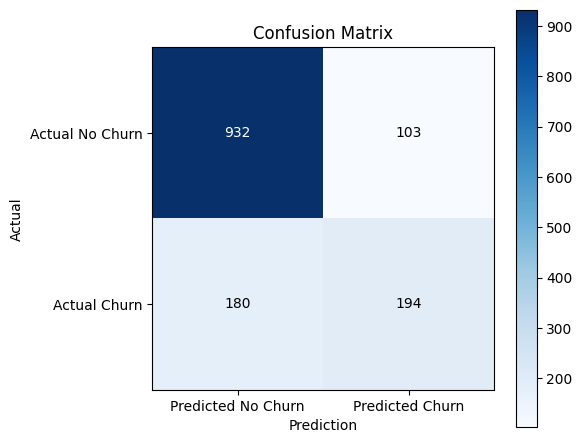

In [ ]:
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix directly here to avoid NameErrors
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

plt.imshow(cm, cmap='Blues')

plt.xticks(
    [0, 1],
    ['Predicted No Churn', 'Predicted Churn']
)

plt.yticks(
    [0, 1],
    ['Actual No Churn', 'Actual Churn']
)

# Adding text annotations to show the exact counts in each quadrant
for i in range(2):
    for j in range(2):
        plt.text(
            j, i, str(cm[i, j]),
            ha='center', va='center',
            color='white' if cm[i, j] > cm.max() / 2.0 else 'black'
        )

plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.colorbar()

plt.tight_layout()
plt.show()

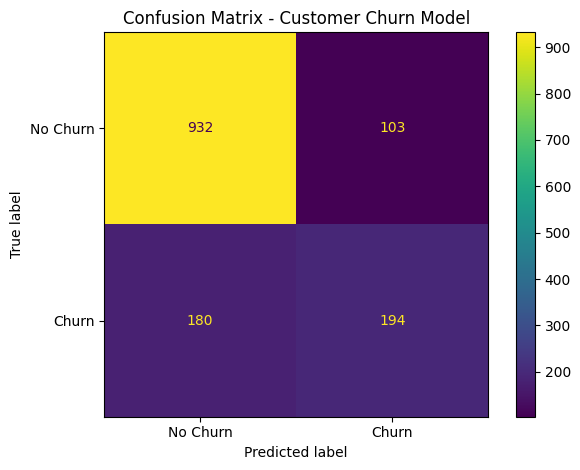

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['No Churn', 'Churn']
)

plt.title('Confusion Matrix - Customer Churn Model')
plt.tight_layout()
plt.show()

In [ ]:
feature_names = preprocessor.get_feature_names_out()

coefficients = logistic_model.coef_[0]

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

feature_importance['Absolute_Coefficient'] = (
    feature_importance['Coefficient'].abs()
)

feature_importance = feature_importance.sort_values(
    'Absolute_Coefficient',
    ascending=False
)

feature_importance.head(20)

,Feature,Coefficient,Absolute_Coefficient
1,num__tenure,-1.131364,1.131364
27,cat__Contract_Two year,-1.010786,1.010786
12,cat__InternetService_Fiber optic,0.879376,0.879376
33,cat__Tenure_Group_Loyal,0.784047,0.784047
4,num__Risk_Score,0.746452,0.746452
2,num__MonthlyCharges,-0.556117,0.556117
9,cat__PhoneService_Yes,-0.497274,0.497274
25,cat__StreamingMovies_Yes,0.449631,0.449631
23,cat__StreamingTV_Yes,0.449122,0.449122
11,cat__MultipleLines_Yes,0.427309,0.427309


In [ ]:
negative_features = (
    feature_importance[
        feature_importance['Coefficient'] < 0
    ]
    .sort_values('Coefficient')
    .head(15)
)

negative_features

,Feature,Coefficient,Absolute_Coefficient
1,num__tenure,-1.131364,1.131364
27,cat__Contract_Two year,-1.010786,1.010786
2,num__MonthlyCharges,-0.556117,0.556117
9,cat__PhoneService_Yes,-0.497274,0.497274
10,cat__MultipleLines_No phone service,-0.353074,0.353074
26,cat__Contract_One year,-0.270803,0.270803
8,cat__Dependents_Yes,-0.212772,0.212772
34,cat__Tenure_Group_New,-0.088259,0.088259
17,cat__OnlineBackup_Yes,-0.071456,0.071456
13,cat__InternetService_No,-0.056742,0.056742


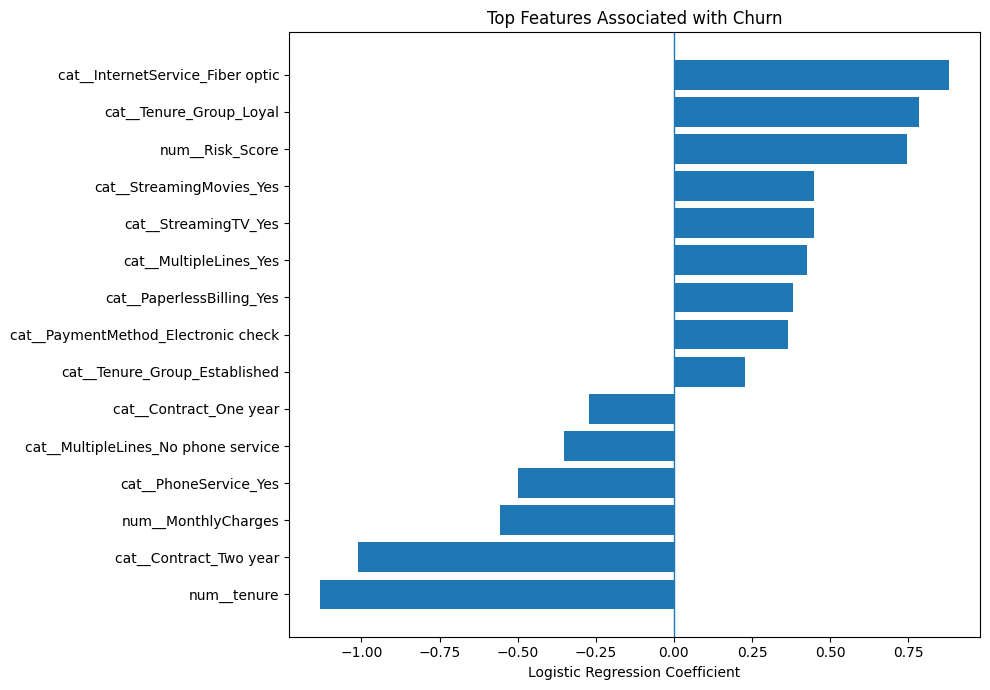

In [ ]:
top_features = feature_importance.head(15).sort_values(
    'Coefficient'
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features['Feature'],
    top_features['Coefficient']
)

plt.axvline(0, linewidth=1)

plt.title('Top Features Associated with Churn')
plt.xlabel('Logistic Regression Coefficient')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf_model.fit(
    X_train_processed,
    y_train
)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [ ]:
rf_pred = rf_model.predict(X_test_processed)

rf_prob = rf_model.predict_proba(
    X_test_processed
)[:, 1]

In [ ]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)

print("Random Forest Results")
print("--------------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_auc, 4))

Random Forest Results
--------------------
Accuracy : 0.7913
Precision: 0.6399
Recall   : 0.4893
F1 Score : 0.5545
ROC-AUC  : 0.8266


In [ ]:
model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy,
        rf_accuracy
    ],
    'Precision': [
        precision,
        rf_precision
    ],
    'Recall': [
        recall,
        rf_recall
    ],
    'F1 Score': [
        f1,
        rf_f1
    ],
    'ROC-AUC': [
        roc_auc,
        rf_auc
    ]
})

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7991,0.6532,0.5187,0.5782,0.8423
1,Random Forest,0.7913,0.6399,0.4893,0.5545,0.8266


In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

threshold_results = []

for threshold in np.arange(0.20, 0.71, 0.05):

    threshold_pred = (
        y_prob >= threshold
    ).astype(int)

    threshold_results.append({
        'Threshold': round(threshold, 2),
        'Precision': precision_score(
            y_test,
            threshold_pred,
            zero_division=0
        ),
        'Recall': recall_score(
            y_test,
            threshold_pred,
            zero_division=0
        ),
        'F1_Score': f1_score(
            y_test,
            threshold_pred,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.round(3)

,Threshold,Precision,Recall,F1_Score
0,0.20,0.477,0.861,0.614
1,0.25,0.494,0.805,0.612
2,0.30,0.525,0.757,0.620
3,0.35,0.557,0.714,0.626
4,0.40,0.582,0.658,0.617
5,0.45,0.606,0.588,0.597
6,0.50,0.653,0.519,0.578
7,0.55,0.681,0.457,0.547
8,0.60,0.710,0.380,0.495
9,0.65,0.742,0.307,0.435


In [ ]:
best_threshold = threshold_df.loc[
    threshold_df['F1_Score'].idxmax()
]

best_threshold

,3
Threshold,0.350000
Precision,0.557411
Recall,0.713904
F1_Score,0.626026


In [ ]:
best_threshold = threshold_df.loc[
    threshold_df['F1_Score'].idxmax()
]

best_threshold

,3
Threshold,0.350000
Precision,0.557411
Recall,0.713904
F1_Score,0.626026


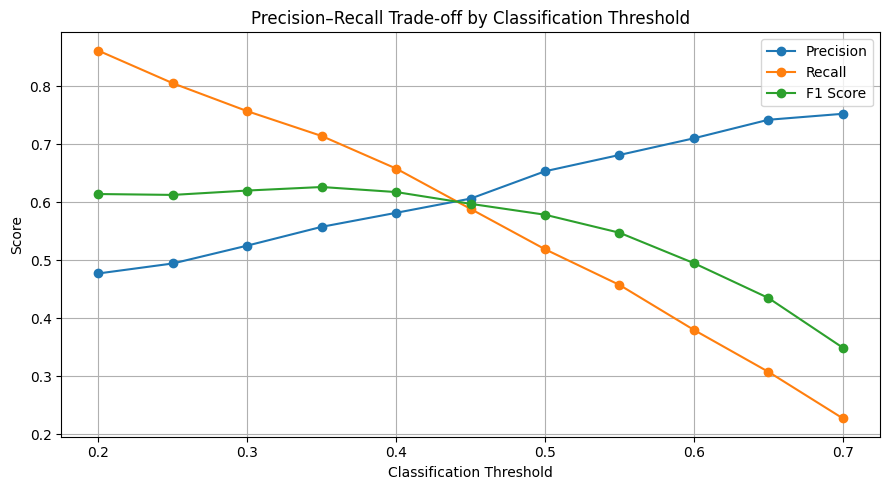

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    threshold_df['Threshold'],
    threshold_df['Precision'],
    marker='o',
    label='Precision'
)

plt.plot(
    threshold_df['Threshold'],
    threshold_df['Recall'],
    marker='o',
    label='Recall'
)

plt.plot(
    threshold_df['Threshold'],
    threshold_df['F1_Score'],
    marker='o',
    label='F1 Score'
)

plt.xlabel('Classification Threshold')
plt.ylabel('Score')
plt.title('Precision–Recall Trade-off by Classification Threshold')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:

optimal_threshold = best_threshold['Threshold']

# Create predictions using the optimized threshold
optimized_pred = (y_prob >= optimal_threshold).astype(int)

print("Optimal Threshold:", optimal_threshold)

Optimal Threshold: 0.35


In [ ]:
optimized_accuracy = accuracy_score(y_test, optimized_pred)
optimized_precision = precision_score(y_test, optimized_pred)
optimized_recall = recall_score(y_test, optimized_pred)
optimized_f1 = f1_score(y_test, optimized_pred)

print("Optimized Model Performance")
print("---------------------------")
print("Accuracy :", round(optimized_accuracy, 4))
print("Precision:", round(optimized_precision, 4))
print("Recall   :", round(optimized_recall, 4))
print("F1 Score :", round(optimized_f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

Optimized Model Performance
---------------------------
Accuracy : 0.7736
Precision: 0.5574
Recall   : 0.7139
F1 Score : 0.626
ROC-AUC  : 0.8423


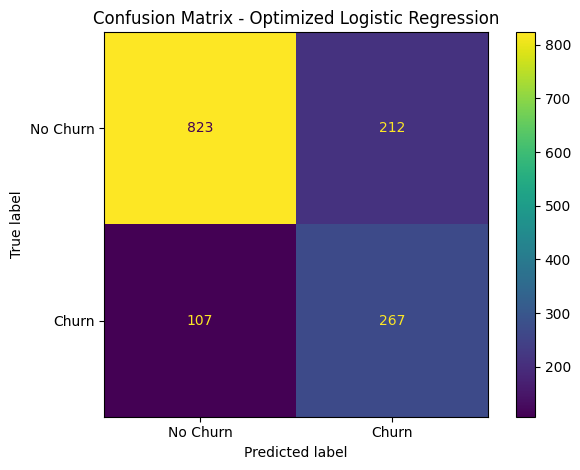

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    optimized_pred,
    display_labels=['No Churn', 'Churn']
)

plt.title('Confusion Matrix - Optimized Logistic Regression')
plt.tight_layout()
plt.show()

In [ ]:
# Prepare the full dataset for prediction
X_full = df_analysis.drop(columns=['customerID', 'Churn', 'Churn_Encoded'])

# Transform using the already-fitted preprocessor
X_full_processed = preprocessor.transform(X_full)

# Predict churn probability
full_churn_probability = logistic_model.predict_proba(X_full_processed)[:, 1]

# Add probability to the dataset
df_predictions = df_analysis.copy()
df_predictions['Churn_Probability'] = full_churn_probability

# Apply optimized threshold
df_predictions['Predicted_Churn'] = (
    df_predictions['Churn_Probability'] >= optimal_threshold
).astype(int)

df_predictions.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Encoded,Tenure_Group,Risk_Score,Lifetime_Revenue,Churn_Probability,Predicted_Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,Electronic check,29.85,29.85,No,0,New,4,29.85,0.618191,1
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Mailed check,56.95,1889.50,No,0,Established,1,1936.30,0.038971,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Mailed check,53.85,108.15,Yes,1,New,3,107.70,0.315459,0
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Bank transfer (automatic),42.30,1840.75,No,0,Established,0,1903.50,0.026353,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,Electronic check,70.70,151.65,Yes,1,New,5,141.40,0.714299,1


In [ ]:
retention_list = df_predictions[
    (df_predictions['Churn'] == 'No') &
    (df_predictions['Predicted_Churn'] == 1)
].copy()

retention_list = retention_list.sort_values(
    ['Churn_Probability', 'MonthlyCharges'],
    ascending=[False, False]
)

retention_list[
    [
        'customerID',
        'Contract',
        'tenure',
        'InternetService',
        'TechSupport',
        'OnlineSecurity',
        'MonthlyCharges',
        'Churn_Probability'
    ]
].head(20)

,customerID,Contract,tenure,InternetService,TechSupport,OnlineSecurity,MonthlyCharges,Churn_Probability
3159,5150-ITWWB,Month-to-month,3,Fiber optic,No,No,94.85,0.874457
3346,2545-EBUPK,Month-to-month,2,Fiber optic,No,No,84.05,0.846128
935,6630-UJZMY,Month-to-month,4,Fiber optic,No,No,83.25,0.841462
4039,8161-QYMTT,Month-to-month,7,Fiber optic,No,No,94.10,0.838871
5474,4912-PIGUY,Month-to-month,1,Fiber optic,No,No,84.60,0.828661
3735,3489-HHPFY,Month-to-month,2,Fiber optic,No,No,84.05,0.828638
4618,6350-XFYGW,Month-to-month,4,Fiber optic,No,No,94.75,0.827893
2519,4927-WWOOZ,Month-to-month,2,Fiber optic,No,No,91.45,0.825646
5140,7577-SWIFR,Month-to-month,1,Fiber optic,No,No,89.25,0.822299
345,0021-IKXGC,Month-to-month,1,Fiber optic,No,No,72.10,0.819212


In [ ]:
potential_monthly_revenue = retention_list['MonthlyCharges'].sum()

print("Customers flagged for retention:", len(retention_list))
print(
    "Potential monthly revenue exposure: ₹",
    round(potential_monthly_revenue, 2)
)

Customers flagged for retention: 995
Potential monthly revenue exposure: ₹ 76408.3


In [ ]:
df_predictions['Risk_Category'] = pd.cut(
    df_predictions['Churn_Probability'],
    bins=[-0.01, 0.30, 0.60, 1.00],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

df_predictions['Risk_Category'].value_counts()

,count
Risk_Category,
Low Risk,4402
Medium Risk,1608
High Risk,1033


In [ ]:
risk_summary = (
    df_predictions
    .groupby('Risk_Category', observed=False)
    .agg(
        Customers=('customerID', 'count'),
        Actual_Churned=('Churn_Encoded', 'sum'),
        Avg_Churn_Probability=('Churn_Probability', 'mean'),
        Monthly_Revenue=('MonthlyCharges', 'sum')
    )
    .reset_index()
)

risk_summary['Actual_Churn_Rate'] = (
    risk_summary['Actual_Churned']
    / risk_summary['Customers'] * 100
).round(2)

risk_summary

,Risk_Category,Customers,Actual_Churned,Avg_Churn_Probability,Monthly_Revenue,Actual_Churn_Rate
0,Low Risk,4402,446,0.097335,252855.2,10.13
1,Medium Risk,1608,678,0.440722,118924.0,42.16
2,High Risk,1033,745,0.711835,84337.4,72.12


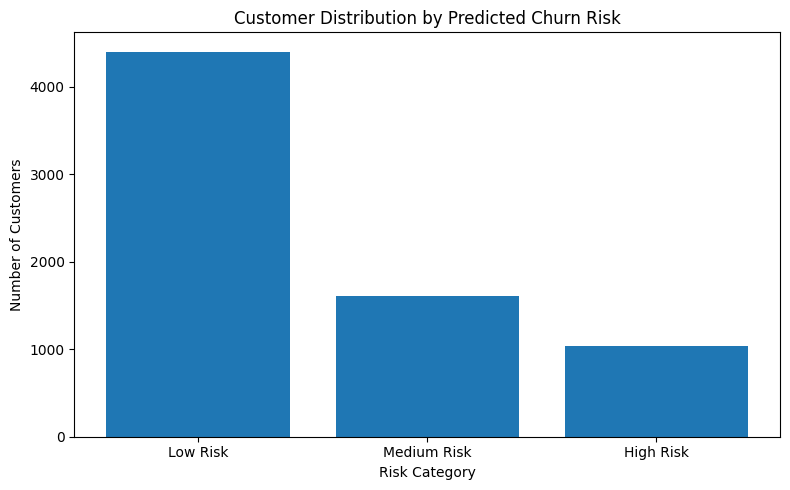

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    risk_summary['Risk_Category'].astype(str),
    risk_summary['Customers']
)

plt.xlabel('Risk Category')
plt.ylabel('Number of Customers')
plt.title('Customer Distribution by Predicted Churn Risk')

plt.tight_layout()
plt.show()

In [ ]:
positive_drivers = feature_importance[
    feature_importance['Coefficient'] > 0
].sort_values(
    'Coefficient',
    ascending=False
)

positive_drivers.head(15)

,Feature,Coefficient,Absolute_Coefficient
12,cat__InternetService_Fiber optic,0.879376,0.879376
33,cat__Tenure_Group_Loyal,0.784047,0.784047
4,num__Risk_Score,0.746452,0.746452
25,cat__StreamingMovies_Yes,0.449631,0.449631
23,cat__StreamingTV_Yes,0.449122,0.449122
11,cat__MultipleLines_Yes,0.427309,0.427309
28,cat__PaperlessBilling_Yes,0.379797,0.379797
30,cat__PaymentMethod_Electronic check,0.366880,0.366880
32,cat__Tenure_Group_Established,0.228988,0.228988
3,num__TotalCharges,0.206248,0.206248


In [ ]:
negative_drivers = feature_importance[
    feature_importance['Coefficient'] < 0
].sort_values(
    'Coefficient',
    ascending=True
)

negative_drivers.head(15)

,Feature,Coefficient,Absolute_Coefficient
1,num__tenure,-1.131364,1.131364
27,cat__Contract_Two year,-1.010786,1.010786
2,num__MonthlyCharges,-0.556117,0.556117
9,cat__PhoneService_Yes,-0.497274,0.497274
10,cat__MultipleLines_No phone service,-0.353074,0.353074
26,cat__Contract_One year,-0.270803,0.270803
8,cat__Dependents_Yes,-0.212772,0.212772
34,cat__Tenure_Group_New,-0.088259,0.088259
17,cat__OnlineBackup_Yes,-0.071456,0.071456
13,cat__InternetService_No,-0.056742,0.056742


In [ ]:
model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Optimized Logistic Regression'
    ],
    'Accuracy': [
        accuracy,
        rf_accuracy,
        optimized_accuracy
    ],
    'Precision': [
        precision,
        rf_precision,
        optimized_precision
    ],
    'Recall': [
        recall,
        rf_recall,
        optimized_recall
    ],
    'F1 Score': [
        f1,
        rf_f1,
        optimized_f1
    ],
    'ROC-AUC': [
        roc_auc,
        rf_auc,
        roc_auc
    ]
})

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7991,0.6532,0.5187,0.5782,0.8423
1,Random Forest,0.7913,0.6399,0.4893,0.5545,0.8266
2,Optimized Logistic Regression,0.7736,0.5574,0.7139,0.6260,0.8423


In [ ]:
model_comparison_display = model_comparison.copy()

metric_columns = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1 Score',
    'ROC-AUC'
]

model_comparison_display[metric_columns] = (
    model_comparison_display[metric_columns] * 100
).round(2)

model_comparison_display

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,79.91,65.32,51.87,57.82,84.23
1,Random Forest,79.13,63.99,48.93,55.45,82.66
2,Optimized Logistic Regression,77.36,55.74,71.39,62.60,84.23


In [ ]:
powerbi_data = df_predictions[
    [
        'customerID',
        'gender',
        'SeniorCitizen',
        'Partner',
        'Dependents',
        'tenure',
        'Tenure_Group',
        'PhoneService',
        'MultipleLines',
        'InternetService',
        'OnlineSecurity',
        'OnlineBackup',
        'DeviceProtection',
        'TechSupport',
        'StreamingTV',
        'StreamingMovies',
        'Contract',
        'PaperlessBilling',
        'PaymentMethod',
        'MonthlyCharges',
        'TotalCharges',
        'Churn',
        'Risk_Score',
        'Lifetime_Revenue',
        'Churn_Probability',
        'Predicted_Churn',
        'Risk_Category'
    ]
].copy()

powerbi_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,Tenure_Group,PhoneService,MultipleLines,InternetService,...,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Risk_Score,Lifetime_Revenue,Churn_Probability,Predicted_Churn,Risk_Category
0,7590-VHVEG,Female,0,Yes,No,1,New,No,No phone service,DSL,...,Yes,Electronic check,29.85,29.85,No,4,29.85,0.618191,1,High Risk
1,5575-GNVDE,Male,0,No,No,34,Established,Yes,No,DSL,...,No,Mailed check,56.95,1889.50,No,1,1936.30,0.038971,0,Low Risk
2,3668-QPYBK,Male,0,No,No,2,New,Yes,No,DSL,...,Yes,Mailed check,53.85,108.15,Yes,3,107.70,0.315459,0,Medium Risk
3,7795-CFOCW,Male,0,No,No,45,Established,No,No phone service,DSL,...,No,Bank transfer (automatic),42.30,1840.75,No,0,1903.50,0.026353,0,Low Risk
4,9237-HQITU,Female,0,No,No,2,New,Yes,No,Fiber optic,...,Yes,Electronic check,70.70,151.65,Yes,5,141.40,0.714299,1,High Risk


In [ ]:
print("Rows:", powerbi_data.shape[0])
print("Columns:", powerbi_data.shape[1])

print("\nMissing values:")
print(powerbi_data.isnull().sum().sum())

print("\nDuplicate rows:")
print(powerbi_data.duplicated().sum())

Rows: 7043
Columns: 27

Missing values:
11

Duplicate rows:
0


In [1]:
powerbi_data = df_predictions[[
    'customerID',
    'gender',
    'SeniorCitizen',
    'Partner',
    'Dependents',
    'tenure',
    'Tenure_Group',
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod',
    'MonthlyCharges',
    'TotalCharges',
    'Churn',
    'Risk_Score',
    'Lifetime_Revenue',
    'Churn_Probability',
    'Predicted_Churn',
    'Risk_Category'
]].copy()

powerbi_data.to_csv(
    '/content/telco_churn_powerbi.csv',
    index=False
)

print("Power BI dataset created successfully!")

NameError: name 'powerbi_data' is not defined

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# 1. Load data
df = pd.read_csv("churn Analysis.csv")
df_clean = df.iloc[:, :21].copy()
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

# 2. Features and Target Setup
df_analysis = df_clean.copy()
df_analysis['Churn_Encoded'] = df_analysis['Churn'].map({'No': 0, 'Yes': 1})
df_analysis['Tenure_Group'] = pd.cut(
    df_analysis['tenure'],
    bins=[-1, 12, 24, 48, 72],
    labels=['New', 'Early', 'Established', 'Loyal']
)
df_analysis['Risk_Score'] = (
    (df_analysis['Contract'] == 'Month-to-month').astype(int)
    + (df_analysis['tenure'] <= 12).astype(int)
    + (df_analysis['InternetService'] == 'Fiber optic').astype(int)
    + (df_analysis['TechSupport'] == 'No').astype(int)
    + (df_analysis['OnlineSecurity'] == 'No').astype(int)
)
df_analysis['Lifetime_Revenue'] = df_analysis['MonthlyCharges'] * df_analysis['tenure']

X = df_analysis.drop(columns=['customerID', 'Churn', 'Churn_Encoded'])
y = df_analysis['Churn_Encoded']

numerical_features = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Risk_Score', 'Lifetime_Revenue']
categorical_features = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Tenure_Group']

# 3. Train Test Split & Fitting Model Pipeline
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)

logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train_processed, y_train)

# 4. Processing Full Dataset for Export
X_full_processed = preprocessor.transform(X)
full_churn_probability = logistic_model.predict_proba(X_full_processed)[:, 1]

df_predictions = df_analysis.copy()
df_predictions['Churn_Probability'] = full_churn_probability

optimal_threshold = 0.35
df_predictions['Predicted_Churn'] = (df_predictions['Churn_Probability'] >= optimal_threshold).astype(int)

df_predictions['Risk_Category'] = pd.cut(
    df_predictions['Churn_Probability'],
    bins=[-0.01, 0.30, 0.60, 1.00],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

powerbi_data = df_predictions[[
    'customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'tenure', 'Tenure_Group', 'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
    'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Risk_Score',
    'Lifetime_Revenue', 'Churn_Probability', 'Predicted_Churn', 'Risk_Category'
]].copy()

powerbi_data.to_csv('/content/telco_churn_powerbi.csv', index=False)
print("Process complete! The final Power BI dataset has been generated and saved to: /content/telco_churn_powerbi.csv")

In [2]:
from google.colab import files

# Trigger browser download for the Power BI CSV file
files.download('/content/telco_churn_powerbi.csv')

FileNotFoundError: Cannot find file: /content/telco_churn_powerbi.csv